# USGS Comparison

Notebook 01 produced an independent post-fire debris flow assessment for the
2024 Bridge Fire. USGS published their own. This notebook compares them.

This is the pipeline-level check that the pfdf cross-validation could not
provide. That comparison proved the model implementation is correct given
identical inputs. It said nothing about whether the ingest produces the right
inputs in the first place.

## Cell 1 — Find the published assessment

USGS archives each 2024 assessment as a child item on ScienceBase. Each one
holds shapefiles for the perimeter, stream segments, catchment basins and
outlet points, plus a field description file and a median thresholds table.

This cell queries the ScienceBase API for the children of the 2024 collection
and finds the Bridge Fire. Nothing is downloaded yet. The point is to see what
is actually in there before deciding how to compare against it.

In [2]:
# Cell 1 --- locate the USGS Bridge Fire assessment on ScienceBase
%cd /content

import requests, json
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

FIRE_DIR = Path('/content/drive/MyDrive/postfire-debris-flow/bridge_2024')
USGS_DIR = FIRE_DIR / 'usgs'
USGS_DIR.mkdir(parents=True, exist_ok=True)

COLLECTION_2024 = '68c325ebd4be0260db1940bf'

r = requests.get(
    'https://www.sciencebase.gov/catalog/items',
    params={'parentId': COLLECTION_2024, 'format': 'json',
            'max': 500, 'fields': 'title,summary,files'},
    timeout=120)
r.raise_for_status()
items = r.json().get('items', [])
print(f'2024 assessments in the collection: {len(items)}\n')

hits = [it for it in items if 'bridge' in it.get('title', '').lower()]
for it in hits:
    print(f"TITLE : {it['title']}")
    print(f"ID    : {it['id']}")
    for f in it.get('files', []):
        print(f"  {f.get('name'):45s} {f.get('size', 0)/1e6:8.2f} MB")
    print()

if not hits:
    print('No "bridge" match. All titles:')
    for it in items:
        print(' ', it.get('title'))

/content
Mounted at /content/drive
2024 assessments in the collection: 105

TITLE : Bridge 2024-09-08 (brd2024) postfire debris-flow hazard assessment
ID    : 68c492e5d4be021a00d8cc52
  Shapefiles.zip                                    4.05 MB
  brd2024-field-descriptions.txt                    0.01 MB
  brd2024-median-thresholds.csv                     0.00 MB
  brd2024-metadata.txt                              0.00 MB
  Bridge_2024-09-08_brd2024_postfire_debris-flow_hazard_assessment.xml     0.02 MB



## Cell 2 — Download and inspect

Four files, about 4 MB total. Small enough to take all of them.

The two text files matter most right now. `field-descriptions.txt` says what
each shapefile column holds and in what units. `metadata.txt` records how this
particular assessment was run, including any parameters the operator changed,
which USGS explicitly notes may happen for individual assessments.

Reading those before writing any comparison code is the difference between
comparing two things that mean the same thing and comparing two things that
merely have similar column names.

Everything is saved to Drive so this only downloads once.

In [3]:
# Cell 2 --- download the assessment and read its documentation

import zipfile
import geopandas as gpd

ITEM_ID = '68c492e5d4be021a00d8cc52'

meta = requests.get(f'https://www.sciencebase.gov/catalog/item/{ITEM_ID}',
                    params={'format': 'json', 'fields': 'files'},
                    timeout=120).json()

for f in meta.get('files', []):
    dest = USGS_DIR / f['name']
    if dest.exists():
        print(f'have  {f["name"]}')
        continue
    resp = requests.get(f['url'], timeout=300)
    resp.raise_for_status()
    dest.write_bytes(resp.content)
    print(f'saved {f["name"]}  ({len(resp.content)/1e6:.2f} MB)')

# Unpack the shapefiles
zpath = USGS_DIR / 'Shapefiles.zip'
shp_dir = USGS_DIR / 'shapefiles'
if zpath.exists() and not shp_dir.exists():
    with zipfile.ZipFile(zpath) as z:
        z.extractall(shp_dir)
print(f'\nExtracted to {shp_dir}')

# What shapefiles are there?
shps = sorted(shp_dir.rglob('*.shp'))
print(f'\n--- {len(shps)} shapefile(s) ---')
for s in shps:
    g = gpd.read_file(s, rows=1)
    print(f'\n{s.name}   crs={g.crs}')
    print(f'  columns: {list(g.columns)}')

# The documentation
for name in ('brd2024-field-descriptions.txt', 'brd2024-metadata.txt'):
    p = USGS_DIR / name
    if p.exists():
        print('\n' + '=' * 72)
        print(name)
        print('=' * 72)
        print(p.read_text(errors='replace'))

have  Shapefiles.zip
have  brd2024-field-descriptions.txt
have  brd2024-median-thresholds.csv
have  brd2024-metadata.txt
have  Bridge_2024-09-08_brd2024_postfire_debris-flow_hazard_assessment.xml

Extracted to /content/drive/MyDrive/postfire-debris-flow/bridge_2024/usgs/shapefiles

--- 4 shapefile(s) ---

brd2024-basins.shp   crs=EPSG:4269
  columns: ['H_16mmh', 'H_16mmh_LG', 'P_16mmh', 'P_16mmh_LG', 'V_16mmh', 'V_16mmh_LG', 'Vmin_16mmh', 'Vmax_16mmh', 'H_20mmh', 'H_20mmh_LG', 'P_20mmh', 'P_20mmh_LG', 'V_20mmh', 'V_20mmh_LG', 'Vmin_20mmh', 'Vmax_20mmh', 'H_24mmh', 'H_24mmh_LG', 'P_24mmh', 'P_24mmh_LG', 'V_24mmh', 'V_24mmh_LG', 'Vmin_24mmh', 'Vmax_24mmh', 'H_28mmh', 'H_28mmh_LG', 'P_28mmh', 'P_28mmh_LG', 'V_28mmh', 'V_28mmh_LG', 'Vmin_28mmh', 'Vmax_28mmh', 'H_32mmh', 'H_32mmh_LG', 'P_32mmh', 'P_32mmh_LG', 'V_32mmh', 'V_32mmh_LG', 'Vmin_32mmh', 'Vmax_32mmh', 'H_34mmh', 'H_34mmh_LG', 'P_34mmh', 'P_34mmh_LG', 'V_34mmh', 'V_34mmh_LG', 'Vmin_34mmh', 'Vmax_34mmh', 'H_36mmh', 'H_36mmh_LG', 'P_

## Cell 3 — Load the USGS results and compare distributions

Their basins shapefile publishes T, F and S directly, using the same
definitions this project uses. That makes the comparison much stronger than
comparing final hazard ratings alone: if the answers differ, the inputs say
which step is responsible.

`I15_50` is their 15-minute rainfall intensity in mm/hr for a 50% probability,
which is the same quantity as this project's `threshold_mm_hr`.

No spatial matching happens here. Their basins and ours are delineated
independently and will not correspond one to one. This cell just puts the two
distributions next to each other, which is enough to see whether the two
assessments are in the same territory before deciding how to align them.

Their data is in EPSG:4269 (NAD83 geographic) and gets reprojected to UTM 11N
to match everything else in this project.

USGS basins :  562   total area    232.7 km2
Ours        :  237   total area    304.9 km2

       variable  USGS_n  USGS_med  USGS_mean  USGS_min  USGS_max  ours_n  ours_med  ours_mean  ours_min  ours_max
              T     562     0.531      0.468     0.000     0.981     237     0.779      0.589     0.000     0.990
              F     562     0.514      0.455    -0.057     0.930     237     0.553      0.465     0.000     1.022
              S     562     0.150      0.161     0.120     0.290     237     0.259      0.270     0.242     0.339
       area_km2     562     0.082      0.414     0.025     7.910     237     0.379      1.286     0.101     7.987
threshold mm/hr     562    21.813     36.758    12.762   216.449     237    16.358     29.008    11.414    84.539

--- Basins with P >= 0.6 at 24 mm/hr ---
USGS: 49.1% of 562 basins
Ours: 63.7% of 237 basins


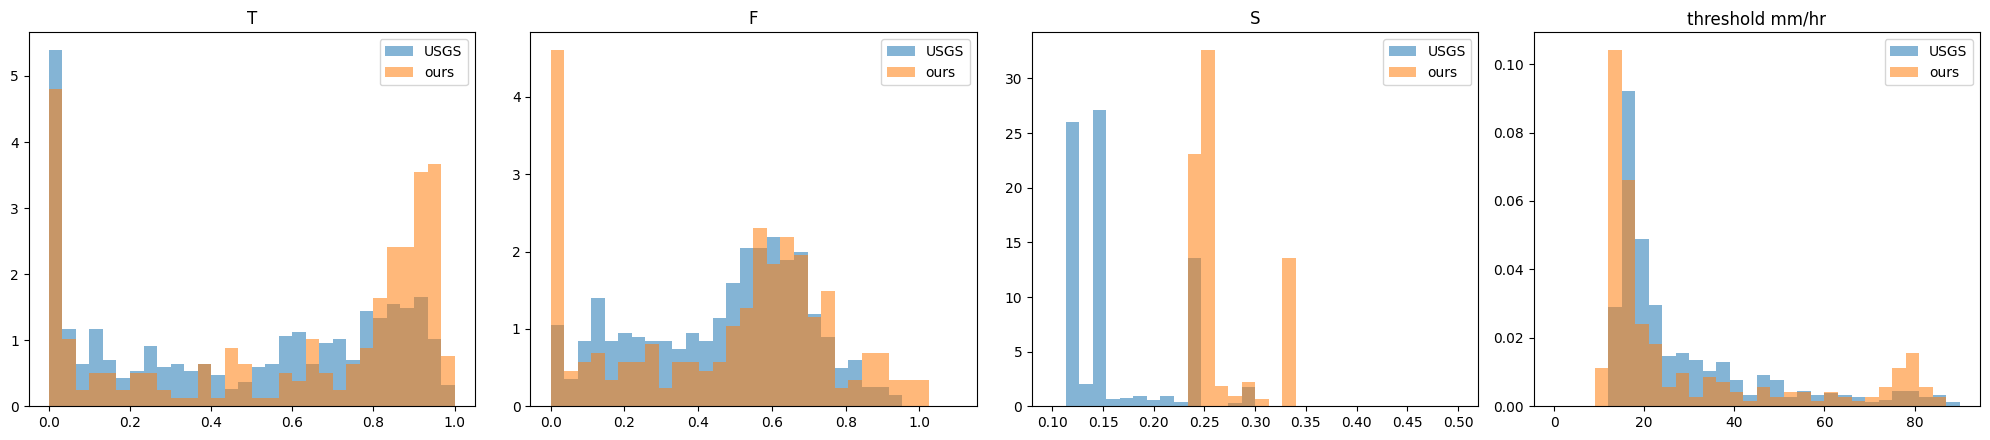


--- USGS published median thresholds ---
    Type    I15_50    I30_50    I60_50   R15_50   R30_50    R60_50    I15_75    I30_75    I60_75   R15_75    R30_75    R60_75
Segments 24.082958 19.350234 15.916855 6.020739 9.675117 15.916855 31.371617 25.238989 21.364347 7.842904 12.619494 21.364347
  Basins 21.813430 17.535406 14.284461 5.453357 8.767703 14.284461 28.415221 22.871864 19.173272 7.103805 11.435932 19.173272


In [4]:
# Cell 3 --- load USGS basins, compare distributions against ours

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TARGET_CRS = 'EPSG:32611'

usgs = gpd.read_file(shp_dir / 'brd2024-basins.shp').to_crs(TARGET_CRS)
usgs['area_km2'] = usgs.geometry.area / 1e6

ours = gpd.read_file(FIRE_DIR / 'model' / 'bridge_2024_basins_scored.geojson')
if ours.crs is None or ours.crs.to_string() != TARGET_CRS:
    ours = ours.to_crs(TARGET_CRS)

print(f'USGS basins : {len(usgs):>4}   total area {usgs.area_km2.sum():8.1f} km2')
print(f'Ours        : {len(ours):>4}   total area {ours.area_km2.sum():8.1f} km2')

rows = []
for var, u_col, o_col in [('T', 'T', 'T'),
                          ('F', 'F', 'F_used'),
                          ('S', 'S', 'S'),
                          ('area_km2', 'area_km2', 'area_km2'),
                          ('threshold mm/hr', 'I15_50', 'threshold_mm_hr')]:
    u = pd.to_numeric(usgs[u_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    o = pd.to_numeric(ours[o_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    rows.append({'variable': var,
                 'USGS_n': len(u), 'USGS_med': u.median(), 'USGS_mean': u.mean(),
                 'USGS_min': u.min(), 'USGS_max': u.max(),
                 'ours_n': len(o), 'ours_med': o.median(), 'ours_mean': o.mean(),
                 'ours_min': o.min(), 'ours_max': o.max()})

print('\n' + pd.DataFrame(rows).round(3).to_string(index=False))

# Hazard split at 24 mm/hr
print('\n--- Basins with P >= 0.6 at 24 mm/hr ---')
u24 = pd.to_numeric(usgs['P_24mmh'], errors='coerce')
o24 = pd.to_numeric(ours['p_24'], errors='coerce')
print(f'USGS: {(u24 >= 0.6).mean():.1%} of {len(u24)} basins')
print(f'Ours: {(o24 >= 0.6).mean():.1%} of {len(o24)} basins')

# Distributions side by side
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))
for a, (title, u_col, o_col, rng) in zip(ax, [
        ('T', 'T', 'T', (0, 1)),
        ('F', 'F', 'F_used', (0, 1.1)),
        ('S', 'S', 'S', (0.1, 0.5)),
        ('threshold mm/hr', 'I15_50', 'threshold_mm_hr', (0, 90))]):
    a.hist(pd.to_numeric(usgs[u_col], errors='coerce').dropna(), bins=30,
           range=rng, alpha=0.55, density=True, label='USGS')
    a.hist(pd.to_numeric(ours[o_col], errors='coerce')
             .replace([np.inf, -np.inf], np.nan).dropna(), bins=30,
           range=rng, alpha=0.55, density=True, label='ours')
    a.set_title(title); a.legend()
plt.tight_layout(); plt.show()

# Their published median thresholds table
mt = pd.read_csv(USGS_DIR / 'brd2024-median-thresholds.csv')
print('\n--- USGS published median thresholds ---')
print(mt.to_string(index=False))

## Cell 4 — Compare on a common grid

The two sets of basins do not correspond. USGS delineated 562 with a median area
of 0.082 km²; this project delineated 237 at 0.379 km². Any rule for matching
them one to one (nearest centroid, largest overlap, containment) would introduce
its own bias, and the choice of rule would drive the result.

So instead of matching basins, both assessments are painted onto the same 10 m
grid the terrain was computed on. Every pixel takes its USGS value from whichever
USGS basin covers it, and its value from this project from whichever of ours
covers it. A difference at a pixel is then a difference in what the two
assessments say about that location, with the basin size difference removed.

This also produces difference maps, which answer a question the summary
statistics cannot: whether the disagreement is spread evenly across the fire or
concentrated in particular places.

**Only pixels covered by both assessments are compared.** Ours extend past the
perimeter, theirs stop at it, and the shared area is what can be compared
honestly. The cell reports how much area that is.

**Note on the threshold comparison.** Their `I15_50` reaches 216 mm/hr on some
basins while ours tops out at 84.5. Those extreme values are basins that barely
burned, where the model is extrapolating hard. The comparison reports both the
full picture and a version restricted to pixels under 60 mm/hr, since a handful
of extreme values would otherwise dominate any average.

Reference grid: 3254 x 4090 at 10 m, EPSG:32611
painted T
painted F
painted S
painted threshold_mm_hr

--- Coverage ---
USGS only     :     13.9 km2
ours only     :     86.2 km2
both          :    218.7 km2
burn area in both:  193.6 km2 (85.4% of the perimeter)

--- Pixelwise comparison over the shared 219 km2 ---
       variable    n_px  USGS_med  ours_med  mean_diff  median_diff   MAE     r
              T 2187087     0.376     0.636      0.146        0.152 0.157 0.921
              F 2187087     0.449     0.478      0.022        0.033 0.050 0.965
              S 2187087     0.144     0.254      0.111        0.110 0.111 0.917
threshold_mm_hr 1909973    24.888    17.762     -6.218       -5.081 6.545 0.877

--- High hazard agreement at 24 mm/hr, by area ---
both High        :    81.4 km2  ( 37.2%)
both not High    :    91.3 km2  ( 41.8%)
ours High only   :    45.9 km2  ( 21.0%)
USGS High only   :     0.2 km2  (  0.1%)

overall agreement: 79.0%
of ground USGS calls High, we agree on 99.

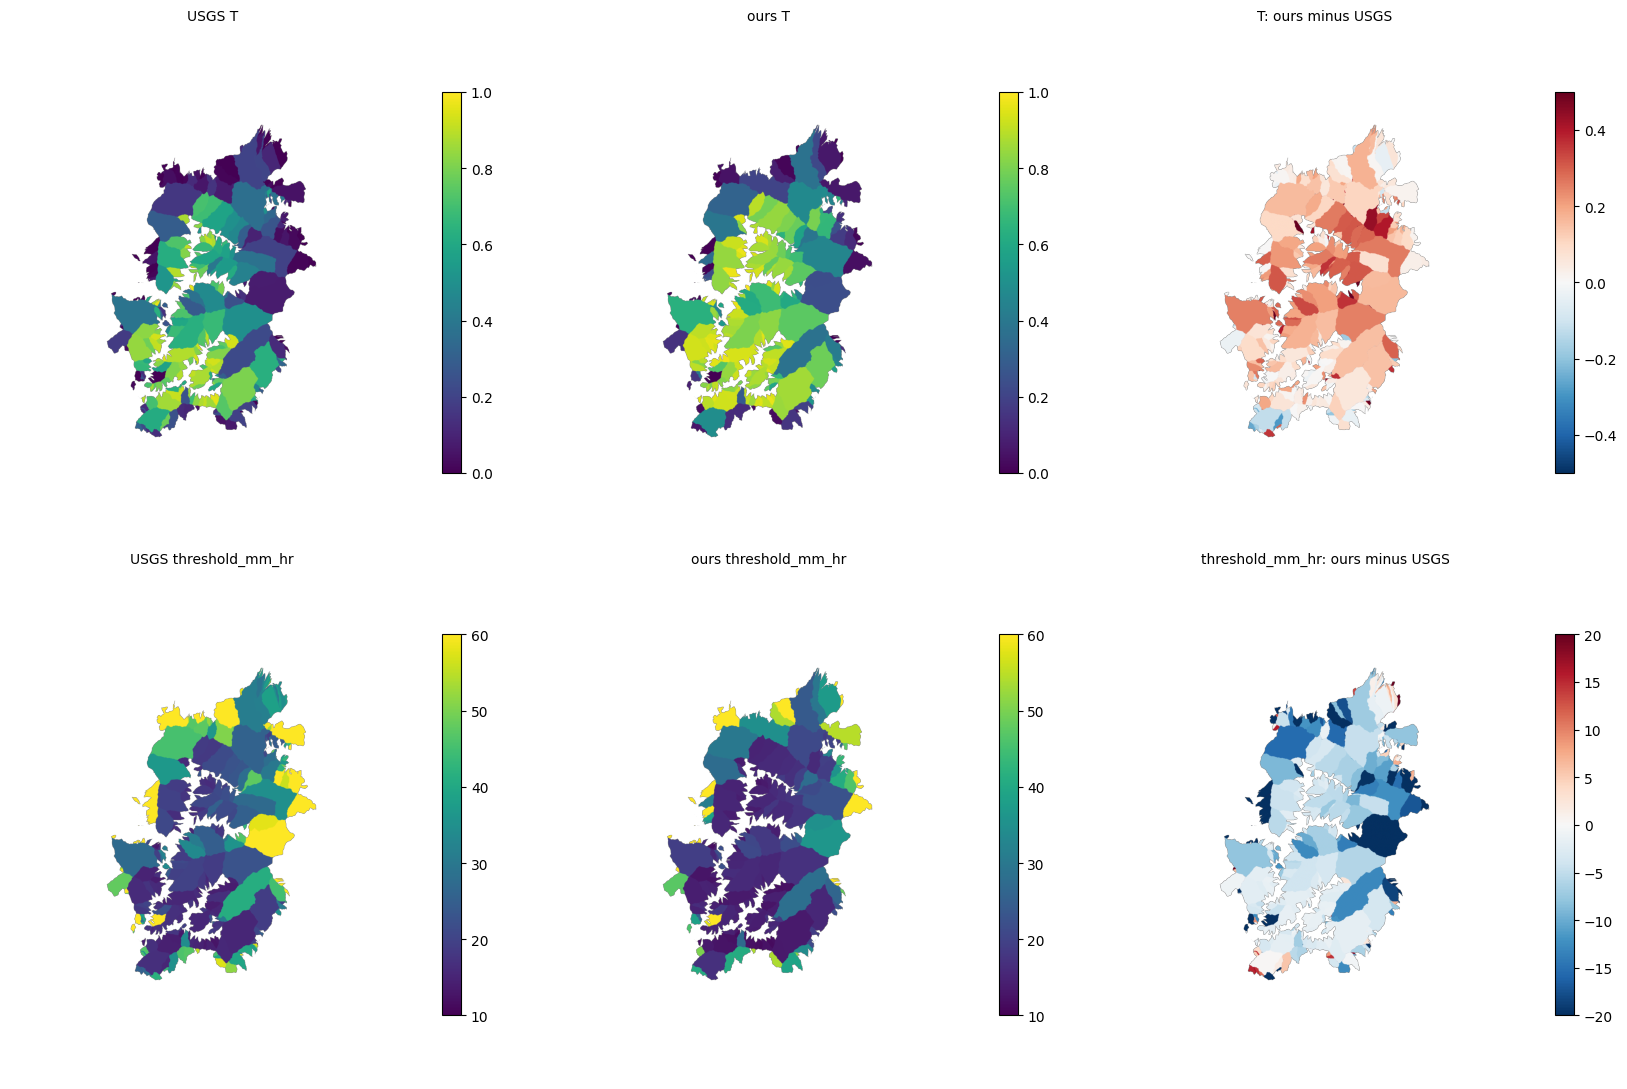

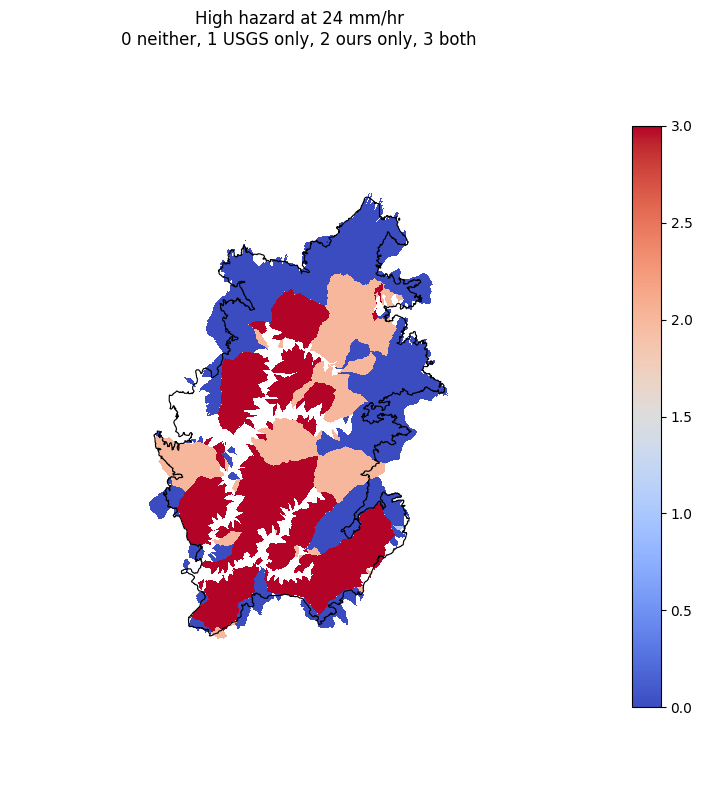

In [5]:
# Cell 4 --- rasterize both assessments onto the shared 10 m grid and compare

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio import features

# --- The reference grid: the basin label raster from notebook 01 -------------
LABEL_PATH = FIRE_DIR / 'terrain' / 'bridge_2024_basin_labels_10m.tif'
with rasterio.open(LABEL_PATH) as src:
    grid_transform = src.transform
    grid_shape = (src.height, src.width)
    grid_crs = src.crs
print(f'Reference grid: {grid_shape[1]} x {grid_shape[0]} at 10 m, {grid_crs}')

perim = gpd.read_file(FIRE_DIR / 'perimeter' / 'bridge_2024_perimeter.geojson').to_crs(TARGET_CRS)
perim_mask = features.rasterize(
    [(perim.geometry.iloc[0], 1)], out_shape=grid_shape,
    transform=grid_transform, fill=0, dtype='uint8').astype(bool)


def paint(gdf, column):
    """Burn one attribute onto the grid, one value per pixel from its basin."""
    vals = pd.to_numeric(gdf[column], errors='coerce') \
             .replace([np.inf, -np.inf], np.nan)
    shapes = [(geom, float(v)) for geom, v in zip(gdf.geometry, vals)
              if geom is not None and not geom.is_empty and v == v]
    return features.rasterize(shapes, out_shape=grid_shape,
                              transform=grid_transform,
                              fill=np.nan, dtype='float32')


PAIRS = [('T', 'T', 'T'),
         ('F', 'F', 'F_used'),
         ('S', 'S', 'S'),
         ('threshold_mm_hr', 'I15_50', 'threshold_mm_hr')]

rast = {}
for name, u_col, o_col in PAIRS:
    rast[name] = (paint(usgs, u_col), paint(ours, o_col))
    print(f'painted {name}')

# --- Where can the two be compared at all? -----------------------------------
u_cov = np.isfinite(rast['T'][0])
o_cov = np.isfinite(rast['T'][1])
both = u_cov & o_cov
cell_km2 = 100 / 1e6

print(f'\n--- Coverage ---')
print(f'USGS only     : {(u_cov & ~o_cov).sum() * cell_km2:8.1f} km2')
print(f'ours only     : {(o_cov & ~u_cov).sum() * cell_km2:8.1f} km2')
print(f'both          : {both.sum() * cell_km2:8.1f} km2')
print(f'burn area in both: {(both & perim_mask).sum() * cell_km2:6.1f} km2 '
      f'({(both & perim_mask).sum() / perim_mask.sum():.1%} of the perimeter)')

# --- Pixelwise agreement ------------------------------------------------------
print(f'\n--- Pixelwise comparison over the shared {both.sum() * cell_km2:.0f} km2 ---')
rows = []
for name, _, _ in PAIRS:
    u, o = rast[name]
    m = both & np.isfinite(u) & np.isfinite(o)
    if name == 'threshold_mm_hr':
        m = m & (u < 60) & (o < 60)      # drop the extrapolating tail
    d = o[m] - u[m]
    rows.append({
        'variable': name, 'n_px': int(m.sum()),
        'USGS_med': float(np.median(u[m])), 'ours_med': float(np.median(o[m])),
        'mean_diff': float(d.mean()), 'median_diff': float(np.median(d)),
        'MAE': float(np.abs(d).mean()),
        'r': float(np.corrcoef(u[m], o[m])[0, 1]),
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))

# --- Do they agree on which ground is dangerous? ------------------------------
u24 = paint(usgs, 'P_24mmh')
o24 = paint(ours, 'p_24')
m = both & np.isfinite(u24) & np.isfinite(o24)
u_high = u24 >= 0.6
o_high = o24 >= 0.6

tp = (m & u_high & o_high).sum()
fp = (m & ~u_high & o_high).sum()
fn = (m & u_high & ~o_high).sum()
tn = (m & ~u_high & ~o_high).sum()
tot = tp + fp + fn + tn

print(f'\n--- High hazard agreement at 24 mm/hr, by area ---')
print(f'both High        : {tp * cell_km2:7.1f} km2  ({tp / tot:6.1%})')
print(f'both not High    : {tn * cell_km2:7.1f} km2  ({tn / tot:6.1%})')
print(f'ours High only   : {fp * cell_km2:7.1f} km2  ({fp / tot:6.1%})')
print(f'USGS High only   : {fn * cell_km2:7.1f} km2  ({fn / tot:6.1%})')
print(f'\noverall agreement: {(tp + tn) / tot:.1%}')
if (tp + fn):
    print(f'of ground USGS calls High, we agree on {tp / (tp + fn):.1%}')
if (tp + fp):
    print(f'of ground we call High, USGS agrees on  {tp / (tp + fp):.1%}')

# --- Maps ---------------------------------------------------------------------
def show(ax, arr, title, **kw):
    a = np.where(both, arr, np.nan)
    im = ax.imshow(a, **kw)
    ax.set_title(title, fontsize=10); ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.75)

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for row, (name, vmin, vmax, dlim) in enumerate([('T', 0, 1, 0.5),
                                                ('threshold_mm_hr', 10, 60, 20)]):
    u, o = rast[name]
    show(axes[row][0], u, f'USGS {name}', cmap='viridis', vmin=vmin, vmax=vmax)
    show(axes[row][1], o, f'ours {name}', cmap='viridis', vmin=vmin, vmax=vmax)
    show(axes[row][2], o - u, f'{name}: ours minus USGS',
         cmap='RdBu_r', vmin=-dlim, vmax=dlim)
plt.tight_layout(); plt.show()

# Where do the two disagree about High?
cat = np.full(grid_shape, np.nan, dtype='float32')
cat[m & u_high & o_high] = 3
cat[m & ~u_high & o_high] = 2
cat[m & u_high & ~o_high] = 1
cat[m & ~u_high & ~o_high] = 0
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cat, cmap='coolwarm', vmin=0, vmax=3, interpolation='nearest')
ax.contour(perim_mask.astype(float), levels=[0.5], colors='black', linewidths=0.8)
ax.set_title('High hazard at 24 mm/hr\n0 neither, 1 USGS only, 2 ours only, 3 both')
ax.axis('off'); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## Cell 5 — Which variable causes the difference?

Cell 4 established that the two assessments agree on where the hazard is and
differ on how much. This cell works out which input is responsible.

Both assessments publish T, F and S for the same ground, so the model can be run
with mixed inputs. Overlaying the two basin sets produces pieces of ground where
both are defined, and each piece gets six numbers: their T, F and S, and ours.

Five runs on those same pieces:

| Run | T | F | S |
|---|---|---|---|
| all USGS | theirs | theirs | theirs |
| all ours | ours | ours | ours |
| swap T | **ours** | theirs | theirs |
| swap F | theirs | **ours** | theirs |
| swap S | theirs | theirs | **ours** |

The distance between the first two runs is the total disagreement. The three swap
runs split that total into a contribution from each variable. This turns "our
thresholds are lower" into "our thresholds are lower, and this much of it comes
from terrain and this much from soil".

**The first run is also a check on the reading.** Feeding their published T, F
and S into this project's model should reproduce their published `I15_50`. If it
does, the comparison is sound. If it does not, then either the fields are being
misread or their assessment was run with modified parameters, which USGS says can
happen for individual assessments.

Everything is area weighted, since the intersection pieces vary enormously in
size and an unweighted average would let slivers count as much as whole
catchments.

intersection pieces: 777
total area         : 218.4 km2
ran all USGS
ran all ours
ran swap T
ran swap F
ran swap S

--- Check: our model fed their inputs, vs their published I15_50 ---
pieces compared : 776
mean difference : -0.0622 mm/hr
max |difference|: 16.8259 mm/hr
correlation     : 0.999610

--- Area-weighted median threshold (mm/hr) ---
     run  median_thr  shift_from_USGS  pct_of_total_gap  area_High_at_24
all USGS      25.768            0.000            -0.000            0.372
all ours      19.327           -6.441           100.000            0.582
  swap T      22.784           -2.984            46.323            0.455
  swap F      25.404           -0.364             5.655            0.381
  swap S      22.933           -2.835            44.009            0.433

Total gap: 25.77 -> 19.33 mm/hr (-6.44)


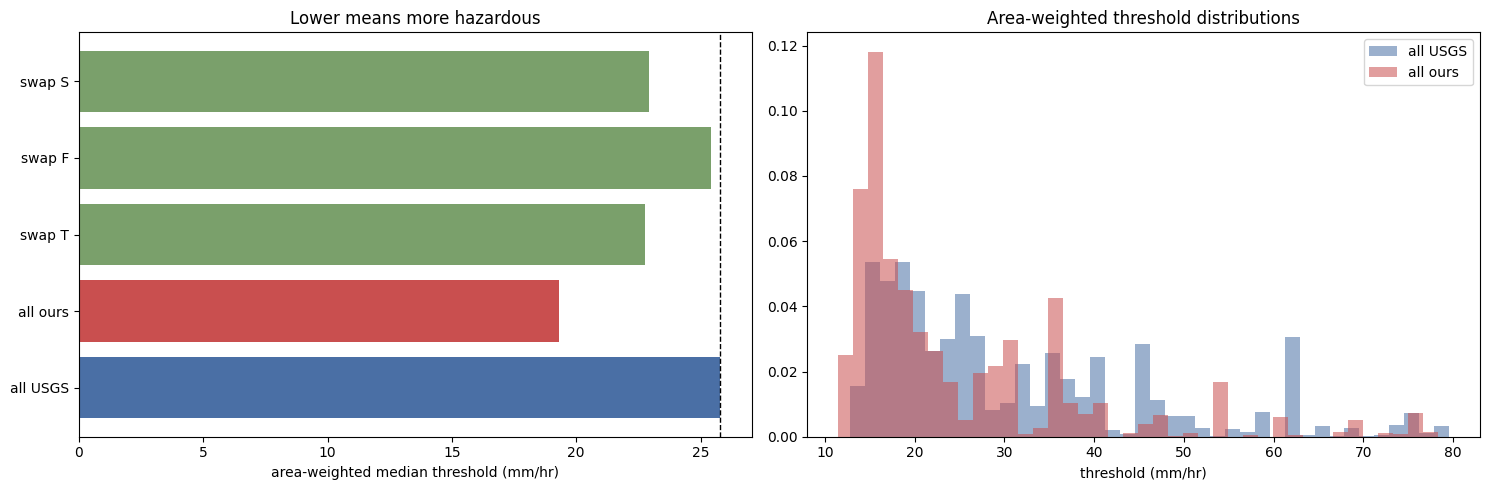

In [ ]:
# Cell 5 --- attribute the difference to T, F or S

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Bring in the tested model ------------------------------------------------
import os, sys, subprocess, importlib
REPO_DIR = '/content/postfire-debris-flow'
if not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', '--quiet',
                    'https://github.com/jerrod-lessel/scar-thresholdscar-threshold.git',
                    REPO_DIR], check=True)
if f'{REPO_DIR}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/src')
from debrisflow import m1
importlib.reload(m1)
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR

# --- Build the intersection pieces -------------------------------------------
u = usgs[['T', 'F', 'S', 'I15_50', 'geometry']].rename(
    columns={'T': 'T_usgs', 'F': 'F_usgs', 'S': 'S_usgs', 'I15_50': 'thr_usgs'})
o = ours[['T', 'F_used', 'S', 'threshold_mm_hr', 'geometry']].rename(
    columns={'T': 'T_ours', 'F_used': 'F_ours', 'S': 'S_ours',
             'threshold_mm_hr': 'thr_ours'})

pieces = gpd.overlay(u, o, how='intersection', keep_geom_type=True)
pieces['area_m2'] = pieces.geometry.area
pieces = pieces[pieces.area_m2 > 1000].copy()          # drop overlay slivers

for c in ['T_usgs', 'F_usgs', 'S_usgs', 'thr_usgs',
          'T_ours', 'F_ours', 'S_ours', 'thr_ours']:
    pieces[c] = pd.to_numeric(pieces[c], errors='coerce')
pieces = pieces.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['T_usgs', 'F_usgs', 'S_usgs', 'T_ours', 'F_ours', 'S_ours'])

# F is a burn magnitude; its floor is no burn. Applied to both sides equally.
pieces['F_usgs'] = pieces.F_usgs.clip(lower=0.0)
pieces['F_ours'] = pieces.F_ours.clip(lower=0.0)

w = pieces.area_m2.to_numpy()
print(f'intersection pieces: {len(pieces):,}')
print(f'total area         : {w.sum() / 1e6:.1f} km2')


def run(T, F, S):
    thr, p24 = [], []
    for t, f, s in zip(T, F, S):
        bv = m1.BasinVariables(T=float(t), F=float(f), S=float(s))
        try:
            thr.append(float(m1.accumulation(bv, target_p=0.5, duration_min=15,
                                             out_convention=INTENSITY)))
        except Exception:
            thr.append(np.inf)
        p24.append(float(m1.likelihood(bv, 24, convention=INTENSITY,
                                       duration_min=15)))
    return np.array(thr), np.array(p24)


COMBOS = {
    'all USGS': ('T_usgs', 'F_usgs', 'S_usgs'),
    'all ours': ('T_ours', 'F_ours', 'S_ours'),
    'swap T':   ('T_ours', 'F_usgs', 'S_usgs'),
    'swap F':   ('T_usgs', 'F_ours', 'S_usgs'),
    'swap S':   ('T_usgs', 'F_usgs', 'S_ours'),
}

results = {}
for label, (tc, fc, sc) in COMBOS.items():
    results[label] = run(pieces[tc], pieces[fc], pieces[sc])
    print(f'ran {label}')


def wmedian(v, weights):
    ok = np.isfinite(v)
    v, weights = v[ok], weights[ok]
    order = np.argsort(v)
    v, weights = v[order], weights[order]
    c = np.cumsum(weights) / weights.sum()
    return float(v[np.searchsorted(c, 0.5)])


# --- Does run 1 reproduce their published threshold? --------------------------
thr_usgs_pub = pieces.thr_usgs.to_numpy()
thr_usgs_calc = results['all USGS'][0]
ok = np.isfinite(thr_usgs_pub) & np.isfinite(thr_usgs_calc) & (thr_usgs_pub < 200)
resid = thr_usgs_calc[ok] - thr_usgs_pub[ok]
print(f'\n--- Check: our model fed their inputs, vs their published I15_50 ---')
print(f'pieces compared : {ok.sum():,}')
print(f'mean difference : {resid.mean():+.4f} mm/hr')
print(f'max |difference|: {np.abs(resid).max():.4f} mm/hr')
print(f'correlation     : {np.corrcoef(thr_usgs_calc[ok], thr_usgs_pub[ok])[0,1]:.6f}')

# --- Attribution --------------------------------------------------------------
base_thr = wmedian(results['all USGS'][0], w)
full_thr = wmedian(results['all ours'][0], w)
print(f'\n--- Area-weighted median threshold (mm/hr) ---')
rows = []
for label in COMBOS:
    thr, p24 = results[label]
    med = wmedian(thr, w)
    high = w[np.isfinite(p24) & (p24 >= 0.6)].sum() / w.sum()
    rows.append({'run': label, 'median_thr': med,
                 'shift_from_USGS': med - base_thr,
                 'pct_of_total_gap': (med - base_thr) / (full_thr - base_thr) * 100
                                     if full_thr != base_thr else np.nan,
                 'area_High_at_24': high})
print(pd.DataFrame(rows).round(3).to_string(index=False))

print(f'\nTotal gap: {base_thr:.2f} -> {full_thr:.2f} mm/hr '
      f'({full_thr - base_thr:+.2f})')

# --- Plot ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
labels = list(COMBOS)
meds = [wmedian(results[l][0], w) for l in labels]
ax[0].barh(labels, meds, color=['#4a6fa5', '#c94f4f', '#7aa06b', '#7aa06b', '#7aa06b'])
ax[0].axvline(base_thr, color='k', ls='--', lw=1)
ax[0].set_xlabel('area-weighted median threshold (mm/hr)')
ax[0].set_title('Lower means more hazardous')

for l, c in zip(['all USGS', 'all ours'], ['#4a6fa5', '#c94f4f']):
    v = results[l][0]
    ax[1].hist(v[np.isfinite(v) & (v < 80)], bins=40, alpha=0.55,
               weights=w[np.isfinite(v) & (v < 80)], density=True, label=l, color=c)
ax[1].set_xlabel('threshold (mm/hr)'); ax[1].legend()
ax[1].set_title('Area-weighted threshold distributions')
plt.tight_layout(); plt.show()

In [7]:
# Cell 5b --- where does the 16.8 mm/hr residual live?
resid_all = np.full(len(pieces), np.nan)
resid_all[ok] = resid
pieces['_resid'] = resid_all

bad = pieces.reindex(pieces._resid.abs().sort_values(ascending=False).index).head(8)
print(bad[['T_usgs', 'F_usgs', 'S_usgs', 'thr_usgs', '_resid', 'area_m2']]
      .assign(area_ha=lambda d: d.area_m2 / 1e4)
      .drop(columns='area_m2').round(4).to_string(index=False))

big = pieces._resid.abs() > 1
print(f'\npieces with |residual| > 1 mm/hr: {big.sum()} of {ok.sum()}')
print(f'their share of total area       : {pieces.area_m2[big].sum() / pieces.area_m2.sum():.2%}')
print(f'median published threshold there: {pieces.thr_usgs[big].median():.1f} mm/hr')
print(f'median published threshold else : {pieces.thr_usgs[~big].median():.1f} mm/hr')

 T_usgs  F_usgs  S_usgs  thr_usgs   _resid  area_ha
    0.0     0.0  0.1500  155.1116 -16.8259   4.2728
    0.0     0.0  0.1229  179.6067 -10.8217  10.5044
    0.0     0.0  0.1500  147.0777  -8.7920   0.4867
    0.0     0.0  0.2400   94.9786  -8.5500  18.7867
    0.0     0.0  0.1200  174.7431  -1.8860   2.6504
    0.0     0.0  0.1200  173.7839  -0.9268   4.4849
    0.0     0.0  0.1500  138.5019  -0.2161  14.6068
    0.0     0.0  0.1500  138.5019  -0.2161   0.1186

pieces with |residual| > 1 mm/hr: 5 of 776
their share of total area       : 0.17%
median published threshold there: 155.1 mm/hr
median published threshold else : 23.8 mm/hr


In [8]:
# Cell 5c --- restrict the check to burned ground
burned_ok = ok & (pieces.T_usgs.to_numpy() > 0) & (pieces.F_usgs.to_numpy() > 0)
r2 = thr_usgs_calc[burned_ok] - thr_usgs_pub[burned_ok]
print(f'burned pieces      : {burned_ok.sum():,}')
print(f'mean difference    : {r2.mean():+.4f} mm/hr')
print(f'max |difference|   : {np.abs(r2).max():.4f} mm/hr')
print(f'correlation        : {np.corrcoef(thr_usgs_calc[burned_ok], thr_usgs_pub[burned_ok])[0,1]:.6f}')

burned pieces      : 703
mean difference    : +0.0000 mm/hr
max |difference|   : 0.0000 mm/hr
correlation        : 1.000000


## Cell 6 — Why is S higher than theirs?

S accounts for 44% of the threshold gap, and the offset is uniform: about +0.11
at nearly every pixel, with the spatial pattern still agreeing at r = 0.917. That
is the signature of a different aggregation rule rather than different data or a
spatial error.

There are four defensible ways to roll STATSGO up to one KF per map unit, and
this project chose one of them. This cell computes all four from the same
downloaded rows and asks which lands closest to the USGS values.

1. **Surface horizon, nulls dropped and renormalised.** The current choice, per
   design decision 3.
2. **Surface horizon, nulls treated as zero.** The rejected alternative. Rock
   outcrop and water contribute 0.0 rather than being excluded.
3. **All horizons averaged, nulls dropped.** Tests whether the surface-only
   restriction is responsible.
4. **Dominant component only.** Takes the single largest component of each map
   unit rather than weighting across them.

A match identifies the exact methodological difference. A non-match is still
worth having: it rules out four explanations and leaves the difference documented
rather than guessed at.

The map unit polygons are already saved from notebook 01, so only the tabular
query runs again.

In [11]:
# Cell 6 --- four ways to aggregate STATSGO, compared against USGS

import numpy as np
import pandas as pd
import geopandas as gpd
from debrisflow import soils
importlib.reload(soils)

SOIL_DIR = FIRE_DIR / 'soils'
mu = gpd.read_file(SOIL_DIR / 'statsgo_mapunits.geojson').to_crs(TARGET_CRS)
mukeys = sorted(mu.mukey.astype(str).unique())
print(f'map units: {len(mukeys)}')

rows = soils.sda_query(soils.kf_by_mapunit_sql(mukeys, dataset='statsgo'))
print(f'horizon rows: {len(rows):,}')

grouped = soils.group_rows_by_component(rows)
print(f'components  : {len(grouped)}')

# group_rows_by_component returns {cokey: {'mukey':..., 'comppct':..., 'horizons':[...]}}
def surface_kf(horizons):
    # Horizons are sorted top-down, each (depth_top_cm, kf).
    return horizons[0][1] if horizons else np.nan

def all_horizon_kf(horizons):
    if not horizons:
        return np.nan
    kfs = [h[1] for h in horizons]
    val, _ = soils.weighted_mean(kfs, [1.0] * len(kfs))
    return val

by_mu = {}
for cokey, comp in grouped.items():
    by_mu.setdefault(str(comp['mukey']), []).append(
        (comp['comppct'], comp['horizons']))

variants = {'1 surface, dropped': {}, '2 surface, zeroed': {},
            '3 all horizons': {}, '4 dominant component': {}}

for mukey, comps in by_mu.items():
    pcts = [c[0] for c in comps]
    surf = [surface_kf(c[1]) for c in comps]
    allh = [all_horizon_kf(c[1]) for c in comps]

    v1, _ = soils.weighted_mean(surf, pcts)
    variants['1 surface, dropped'][mukey] = v1

    surf0 = [0.0 if (v != v) else v for v in surf]
    v2, _ = soils.weighted_mean(surf0, pcts)
    variants['2 surface, zeroed'][mukey] = v2

    v3, _ = soils.weighted_mean(allh, pcts)
    variants['3 all horizons'][mukey] = v3

    variants['4 dominant component'][mukey] = surf[int(np.argmax(pcts))]

print('\n--- KF per map unit under each rule ---')
tab = pd.DataFrame(variants)
tab.index.name = 'mukey'
print(tab.round(4).to_string())

# --- Area weight each variant onto our basins, compare to USGS ----------------
inter = gpd.overlay(ours[['id', 'geometry']], mu[['mukey', 'geometry']],
                    how='intersection', keep_geom_type=True)
inter['area_m2'] = inter.geometry.area
inter['mukey'] = inter.mukey.astype(str)

basin_S = {}
for name, lookup in variants.items():
    out = []
    for bid, grp in inter.groupby('id'):
        kfs = [lookup.get(k, np.nan) for k in grp.mukey]
        val, _ = soils.weighted_mean(kfs, grp.area_m2.tolist())
        out.append({'id': bid, name: val})
    basin_S[name] = pd.DataFrame(out).set_index('id')[name]

S_df = pd.concat(basin_S.values(), axis=1)
usgs_S_med = pd.to_numeric(usgs['S'], errors='coerce').median()

print(f'\n--- Basin S under each rule, vs USGS median of {usgs_S_med:.3f} ---')
summary = S_df.describe().T[['mean', '50%', 'min', 'max']]
summary['dist_from_USGS'] = (summary['50%'] - usgs_S_med).abs()
print(summary.round(4).sort_values('dist_from_USGS').to_string())

best = summary.dist_from_USGS.idxmin()
print(f'\nclosest rule: {best}')
print(f'  its median {summary.loc[best, "50%"]:.4f} vs USGS {usgs_S_med:.4f}')

map units: 10
horizon rows: 465
components  : 158

--- KF per map unit under each rule ---
        1 surface, dropped  2 surface, zeroed  3 all horizons  4 dominant component
mukey                                                                              
660456              0.2967             0.2878          0.2796                  0.32
660470              0.2674             0.1765          0.2793                   NaN
660471              0.2715             0.2715          0.2628                  0.20
660474              0.2432             0.1970          0.2356                   NaN
660484              0.2121             0.1994          0.2535                  0.20
660494              0.2415             0.2125          0.2443                  0.20
660499              0.2628             0.2234          0.2684                  0.24
660500              0.2440             0.1586          0.2422                   NaN
660501              0.3390             0.3153          0.3395        

In [12]:
# Diagnostic --- what is SDA actually returning?
import requests

print('1. Connection smoke test')
try:
    print('   ', soils.check_sda_connection())
except Exception as e:
    print('   FAILED:', type(e).__name__, e)

print('\n2. Raw response to the actual query')
sql = soils.kf_by_mapunit_sql(mukeys, dataset='statsgo')
r = requests.post('https://sdmdataaccess.sc.egov.usda.gov/Tabular/post.rest',
                  json={'query': sql, 'format': 'JSON'}, timeout=120)
print('   status     :', r.status_code)
print('   content-type:', r.headers.get('content-type'))
print('   length     :', len(r.text))
print('   first 400 chars:')
print(r.text[:400] if r.text else '   (empty body)')

1. Connection smoke test
    [['US', 'United States']]

2. Raw response to the actual query
   status     : 200
   content-type: application/json; charset=utf-8
   length     : 19594
   first 400 chars:
{"Table":[["660456","14183976","20",".32","0","30"],["660456","14183976","20",".32","30","127"],["660456","14183976","20",".20","127","152"],["660456","14183967","14",".32","0","58"],["660456","14183967","14",".32","58","130"],["660456","14183967","14",".28","130","183"],["660456","14183974","9",".32","0","36"],["660456","14183962","9",".20","0","30"],["660456","14183962","9",".32","30","127"],["6


## Cell 7 — Does SSURGO explain the rest of the soil gap?

Zeroing null KF values moved S from 0.259 to 0.197 against the USGS median of
0.150, closing 57% of the difference. Something else accounts for the remaining
0.047.

The obvious candidate is the dataset itself. This project used STATSGO on the
grounds that M1 was calibrated against it. If the USGS assessment was run on
SSURGO instead, that would combine with the null-handling rule to explain the
whole gap.

SSURGO is the finer survey: where STATSGO gave 10 map units across the whole
226 km² fire, SSURGO will give hundreds or thousands. That is the point of it,
and it is also the risk.

**Soil Data Access truncates large responses rather than raising an error.** A
query that returns too much comes back silently short, and a soil layer with
holes in it produces S values that look completely normal. So this cell queries
in tiles, and then verifies that the returned polygons actually cover the basins
before any number computed from them is trusted. If coverage fails, the cell says
so and the result is discarded.

Both aggregation rules are computed on SSURGO, giving four combinations in total
across the two datasets. That separates the two effects instead of confounding
them.

Querying SSURGO in 16 tiles over [-117.8155, 34.1828, -117.601, 34.44]
  tile 0,0:    24 polygon(s)
  tile 0,1:    13 polygon(s)
  tile 0,2:     7 polygon(s)
  tile 0,3:    66 polygon(s)
  tile 1,0:    29 polygon(s)
  tile 1,1:    18 polygon(s)
  tile 1,2:     6 polygon(s)
  tile 1,3:    55 polygon(s)
  tile 2,0:    32 polygon(s)
  tile 2,1:    11 polygon(s)
  tile 2,2:    14 polygon(s)
  tile 2,3:    70 polygon(s)
  tile 3,0:    19 polygon(s)
  tile 3,1:    13 polygon(s)
  tile 3,2:    31 polygon(s)
  tile 3,3:    48 polygon(s)

SSURGO polygons: 314  distinct mukeys: 89

--- SSURGO coverage of our basins ---
basins with any coverage : 237 of 237
median coverage          : 1.0000
minimum coverage         : 1.0000
basins below 0.99        : 0

coverage acceptable: True

SSURGO horizon rows: 570
SSURGO components  : 212 across 86 map units

--- All rules, vs USGS median of 0.150 ---
                        mean     50%     min     max  dist_from_USGS
2 surface, zeroed     0.2103  0.1967 

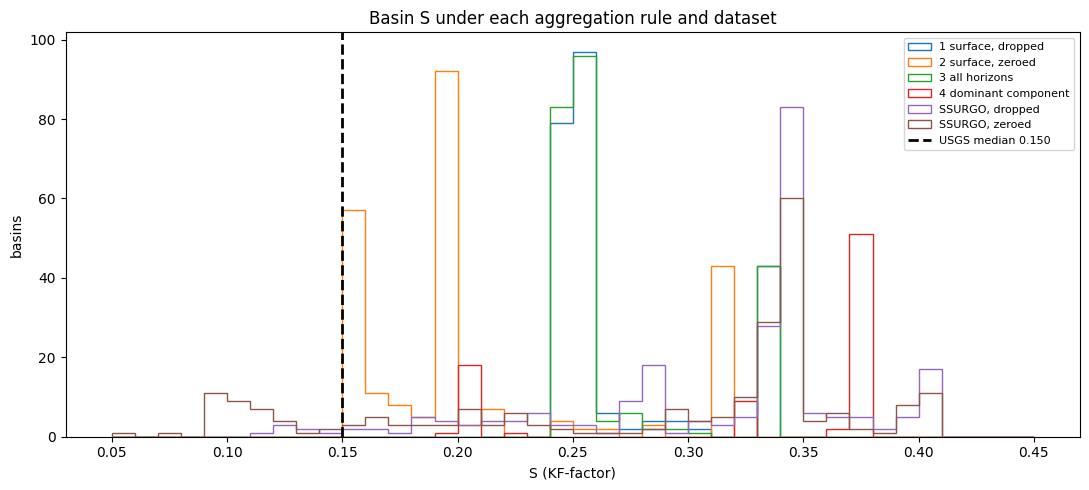

In [13]:
# Cell 7 --- SSURGO, queried in tiles and verified for coverage

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt as shapely_wkt
from shapely.geometry import box as shp_box

N_TILES = 4          # 4x4 grid over the basin extent
MUKEY_BATCH = 200    # map units per tabular query

bounds4326 = ours.to_crs('EPSG:4326').total_bounds
xs = np.linspace(bounds4326[0], bounds4326[2], N_TILES + 1)
ys = np.linspace(bounds4326[1], bounds4326[3], N_TILES + 1)
print(f'Querying SSURGO in {N_TILES * N_TILES} tiles over {np.round(bounds4326, 4).tolist()}')

records, failures = [], []
for i in range(N_TILES):
    for j in range(N_TILES):
        tile = shp_box(xs[i], ys[j], xs[i + 1], ys[j + 1]).buffer(0.002)
        sql = ("SELECT G.mukey, G.mupolygongeo.STAsText() AS geom "
               "FROM mupolygon AS G "
               "WHERE G.mupolygongeo.STIntersects("
               f"geometry::STGeomFromText('{tile.wkt}', 4326)) = 1")
        try:
            r = soils.sda_query(sql, timeout=300)
        except Exception as e:
            failures.append((i, j, f'{type(e).__name__}: {e}'))
            print(f'  tile {i},{j}: FAILED {type(e).__name__}')
            continue
        n = len(r) if r else 0
        print(f'  tile {i},{j}: {n:5d} polygon(s)')
        if n >= 100000:
            failures.append((i, j, 'possible truncation, hit the row cap'))
        for row in (r or []):
            records.append((str(row[0]), row[1]))   # (mukey, wkt string)

if failures:
    print('\nWARNING: some tiles failed or may be truncated:')
    for f in failures:
        print('  ', f)

# Deduplicate polygons returned by more than one tile
# NOTE: the loop variable is `wkt_str`, deliberately not `w`. `w` holds the
# piece-area weights from cell 5, and reusing the name here silently replaced an
# array with a string, which then failed several cells later.
seen, geoms, keys = set(), [], []
for mukey, wkt_str in records:
    h = (mukey, hash(wkt_str))
    if h in seen:
        continue
    seen.add(h)
    keys.append(mukey)
    geoms.append(shapely_wkt.loads(wkt_str))

ss = gpd.GeoDataFrame({'mukey': keys}, geometry=geoms, crs='EPSG:4326').to_crs(TARGET_CRS)
ss['geometry'] = ss.geometry.buffer(0)
print(f'\nSSURGO polygons: {len(ss):,}  distinct mukeys: {ss.mukey.nunique():,}')

# --- Coverage check: do these polygons actually cover the basins? -------------
cov = gpd.overlay(ours[['id', 'geometry']], ss[['mukey', 'geometry']],
                  how='intersection', keep_geom_type=True)
cov['area_m2'] = cov.geometry.area
covered = cov.groupby('id').area_m2.sum()
basin_area = ours.set_index('id').geometry.area
frac = (covered / basin_area).dropna()

print(f'\n--- SSURGO coverage of our basins ---')
print(f'basins with any coverage : {len(frac)} of {len(ours)}')
print(f'median coverage          : {frac.median():.4f}')
print(f'minimum coverage         : {frac.min():.4f}')
print(f'basins below 0.99        : {(frac < 0.99).sum()}')

TRUSTWORTHY = (len(frac) == len(ours)) and (frac.min() > 0.95) and not failures
print(f'\ncoverage acceptable: {TRUSTWORTHY}')
if not TRUSTWORTHY:
    print('>>> The SSURGO layer has gaps. Numbers below are NOT trustworthy.')
    print('>>> Increase N_TILES and re-run before drawing any conclusion.')

# --- Tabular KF for the SSURGO map units, batched ------------------------------
ss_mukeys = sorted(ss.mukey.unique())
kf_rows = []
for k in range(0, len(ss_mukeys), MUKEY_BATCH):
    batch = ss_mukeys[k:k + MUKEY_BATCH]
    kf_rows.extend(soils.sda_query(
        soils.kf_by_mapunit_sql(batch, dataset='ssurgo'), timeout=300) or [])
print(f'\nSSURGO horizon rows: {len(kf_rows):,}')

ss_grouped = soils.group_rows_by_component(kf_rows)
ss_by_mu = {}
for cokey, comp in ss_grouped.items():
    ss_by_mu.setdefault(str(comp['mukey']), []).append(
        (comp['comppct'], comp['horizons']))
print(f'SSURGO components  : {len(ss_grouped):,} across {len(ss_by_mu):,} map units')

ss_dropped, ss_zeroed = {}, {}
for mukey, comps in ss_by_mu.items():
    pcts = [c[0] for c in comps]
    surf = [surface_kf(c[1]) for c in comps]
    ss_dropped[mukey], _ = soils.weighted_mean(surf, pcts)
    ss_zeroed[mukey], _ = soils.weighted_mean(
        [0.0 if (v != v) else v for v in surf], pcts)

# --- S per basin under both SSURGO rules --------------------------------------
def basin_S_from(lookup, inter_df):
    out = []
    for bid, grp in inter_df.groupby('id'):
        kfs = [lookup.get(str(k), np.nan) for k in grp.mukey]
        val, c = soils.weighted_mean(kfs, grp.area_m2.tolist())
        out.append({'id': bid, 'S': val, 'coverage': c})
    return pd.DataFrame(out).set_index('id')

ss_S_drop = basin_S_from(ss_dropped, cov)['S'].rename('SSURGO, dropped')
ss_S_zero = basin_S_from(ss_zeroed, cov)['S'].rename('SSURGO, zeroed')

all_S = pd.concat([S_df, ss_S_drop, ss_S_zero], axis=1)
summary = all_S.describe().T[['mean', '50%', 'min', 'max']]
summary['dist_from_USGS'] = (summary['50%'] - usgs_S_med).abs()

print(f'\n--- All rules, vs USGS median of {usgs_S_med:.3f} ---')
print(summary.round(4).sort_values('dist_from_USGS').to_string())

best = summary.dist_from_USGS.idxmin()
print(f'\nclosest: {best}  (median {summary.loc[best, "50%"]:.4f})')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 5))
for col in all_S.columns:
    v = all_S[col].dropna()
    if len(v):
        ax.hist(v, bins=40, range=(0.05, 0.45), histtype='step', lw=1.8, label=col)
ax.axvline(usgs_S_med, color='k', ls='--', lw=2, label=f'USGS median {usgs_S_med:.3f}')
ax.set_xlabel('S (KF-factor)'); ax.set_ylabel('basins'); ax.legend(fontsize=8)
ax.set_title('Basin S under each aggregation rule and dataset')
plt.tight_layout(); plt.show()

---
# Findings

## What was compared

USGS published their own assessment for this fire (`brd2024`, assessment date
2024-09-28). They publish T, F and S per catchment using the same definitions
this project uses, which lets the comparison reach the inputs rather than
stopping at the outputs.

The two basin sets do not correspond: 562 catchments at a median of 0.082 km²
against 237 at 0.379 km². So the assessments were compared on a shared 10 m grid
and on the polygon intersections of the two sets, rather than by matching basins.

Two differences in the source material are worth stating up front. Their
perimeter is 221.3 km² against the 226.6 km² CAL FIRE FRAP perimeter used here, a
2.4% difference. And their assessment date is one day before this project's
post-fire scene, so they necessarily used different imagery.

## The model reproduces their published output

Feeding USGS's own T, F and S into this project's `m1.py` and comparing against
their published `I15_50`:

| | |
|---|---|
| burned pieces compared | 703 |
| mean difference | 5.1e-15 mm/hr |
| max absolute difference | 4.7e-13 mm/hr |
| correlation | 1.000000 |

Those residuals are at the limit of float64 precision on values around 25, so the
two agree as closely as floating point allows.

**What this check is and is not.** It is not a stronger version of the `pfdf`
cross-validation. Both tests reproduce the same published equation, and both
would have to agree. Its value is different and specific: it confirms that this
project reads USGS's published fields and units correctly, and that this
particular assessment was run with stock M1 parameters rather than the
modifications USGS says operational personnel sometimes make. Both of those are
prerequisites for the attribution analysis below, which would otherwise be
meaningless.

Five pieces of unburned ground (T = 0, F = 0, 0.17% of the area) did not
reproduce. On those, three pieces share identical published inputs but carry
three different published thresholds, so their stored values are not
self-consistent, most likely because the published S is rounded while the model
ran at full precision. With T and F at zero the threshold depends on S alone and
is highly sensitive to that rounding. Those pieces are extrapolations well
outside the model's calibration range and are excluded.

## Where the two assessments agree and differ

Over the 218.7 km² both cover:

| Variable | correlation | median difference (ours minus theirs) |
|---|---|---|
| F | 0.965 | +0.033 |
| T | 0.921 | +0.152 |
| S | 0.917 | +0.110 |
| threshold | 0.877 | -5.08 mm/hr |

These are computed per pixel, but the underlying values are constant within each
catchment, so the effective sample size is in the hundreds rather than the
millions of pixels compared. They are descriptive of spatial agreement, not
statistical tests. One inconsistency to note: the F comparison uses this
project's clamped F against their unclamped F, which biases the F difference
slightly positive. Their F reaches -0.057 at minimum.

**The disagreement is one-directional.** Of ground USGS rates High at 24 mm/hr,
this assessment agrees on 99.8%. Of ground this assessment rates High, USGS
agrees on 63.9%. Only 0.2 km² out of 218.7 is High for them and not for us. The
two assessments agree on where the hazard is and differ on how much, with this
project consistently more hazardous.

**The F agreement is the most informative single result.** Their field
description defines F as mean catchment dNBR divided by 1000, the same as here,
and the two agree at r = 0.965 despite different imagery and entirely separate
processing. So the two pipelines agree on dNBR itself. That matters for how the
vegetation-versus-soil severity caveat should be read: it applies to the
moderate/high classification inside T, not to the dNBR measurement.

## Attribution: which variable causes the gap

Running the model on the same ground with mixed inputs, one variable swapped at a
time. Because the model is a logistic and its inverse, and therefore non-linear,
the swaps were run in both directions: away from the USGS values, and away from
this project's. All figures are area weighted.

| Run | median threshold (mm/hr) | share of the gap |
|---|---|---|
| all USGS | 25.77 | baseline |
| swap T only | 22.78 | 46.3% |
| swap S only | 22.93 | 44.0% |
| swap F only | 25.40 | 5.7% |
| all ours | 19.33 | 100% |

Repeating the exercise from the all-ours baseline gives different shares for two
of the three variables:

| Variable | from USGS baseline | from our baseline | reported range |
|---|---|---|---|
| T, terrain | 46.3% | 48.0% | **46 to 48%** |
| S, soil | 44.0% | 33.9% | **34 to 44%** |
| F, burn severity | 5.7% | 15.9% | **6 to 16%** |

**Terrain is the one firm number.** Under 2 percentage points of spread between
directions, so T accounts for roughly half the 6.4 mm/hr gap regardless of where
the measurement starts.

**Soil and severity are not point estimates.** Both move by about 10 percentage
points depending on the baseline, and they trade against each other: measured
from this project's side, F matters more and S matters less. That is the model's
non-linearity showing, and it is the reason a single-baseline attribution would
have been misleading. Reporting these as ranges is the defensible form.

The shares sum to 96.0% measured one way and 97.7% the other, so interaction
between the variables is small in both directions even though the individual
shares move.

**The T share is confounded with basin size.** Their catchments are roughly five
times smaller than this project's, and basin size affects T directly: a small
basin sits on one hillslope and takes extreme values, while a larger one averages
across ridges and gullies. The 46 to 48% is therefore the combined effect of
delineation scale and any genuine difference in slope or severity classification,
and those two are not separated here.

## Why S differs

The S offset is uniform: about +0.11 at nearly every pixel, with the spatial
pattern still agreeing at r = 0.917. That points to a different aggregation rule
rather than different data or a spatial error.

Six candidate rules were computed from the same source data. Their medians are
over this project's 237 basins, against a USGS median over their 562 smaller
catchments, so the comparison is approximate; the pixelwise figures above (0.254
against 0.144) are the sound version and agree.

| Rule | median S |
|---|---|
| STATSGO, surface horizon, nulls zeroed | 0.197 |
| STATSGO, surface horizon, divided by 100 rather than renormalised | 0.197 |
| STATSGO, all horizons, nulls dropped | 0.256 |
| **STATSGO, surface horizon, nulls dropped (this project)** | **0.259** |
| SSURGO, surface horizon, nulls zeroed | 0.331 |
| SSURGO, surface horizon, nulls dropped | 0.341 |
| STATSGO, dominant component only | 0.370 |

**Zeroing null KF values is the closest of the six**, moving S from 0.259 to 0.197
against the USGS median of 0.150 and closing 57% of the difference. Four of the
ten STATSGO map units here have no KF on their dominant component, which is rock
outcrop, so this fire is unusually exposed to that choice.

This is suggestive, not identification. Matching a median does not establish a
rule, and the USGS field description says only "mean catchment KF-factor" without
specifying horizon, null handling or component weighting.

One further candidate was tested and eliminated. STATSGO component percentages do
not always sum to 100, and an implementation that divides by 100 rather than
renormalising over the components present would produce a systematically lower S.
Two additional rules were computed on that basis and returned values identical to
the zeroed rule at four decimal places on every map unit, because all ten map
units in this fire have components summing to exactly 100. There is nothing for
that mechanism to explain here.

**SSURGO was tested and ruled out.** It moves S further from the USGS values, not
closer. Coverage was verified at 1.0000 across all 237 basins with no truncated
tiles, so this is a real result rather than a data gap. It also supports keeping
STATSGO for headline numbers, which was design decision 4.

## An observation about basin size

USGS's catchments have a median area of 0.082 km². This project cites 0.1 to
8 km² as the range M1 was calibrated on and flags anything outside it as an
extrapolation. By that rule, more than half of the USGS operational catchments
would be flagged.

That is worth resolving rather than leaving implicit. Either the calibration
range is being cited too strictly here, or operational practice routinely works
below it. It also means the delineation scale difference is not simply this
project being coarse: the two assessments sit on opposite sides of a threshold
this project treats as meaningful.

## What this changes

- The model implementation is verified against both the USGS reference package
  and USGS published output.
- The ingest has been compared against an independent operational assessment. It
  agrees closely on dNBR, agrees on spatial pattern for all three variables, and
  is systematically more hazardous, with the difference falling roughly equally
  on terrain and soil.
- The terrain difference is not yet separated from the delineation scale
  difference, and the soil rule is inferred rather than identified.

## Suggested follow-ups

1. ~~Run the reverse swaps and report the attribution as a range if the
   directions disagree~~ **done.** They disagree for S and F, and those are now
   reported as ranges.
2. ~~Test the component-percentage normalisation as a seventh soil rule~~
   **done.** Eliminated: all ten map units sum to 100.
3. Resolve the basin size question. This is now the largest open item, since
   terrain is confidently about half the gap but the delineation scale component
   of it is not separated. Adding delineation scale as a sensitivity axis, run at
   a minimum area closer to the USGS median of 0.082 km², would quantify it.
4. The residual 0.047 in S remains unexplained. Two mechanisms have been tested
   and eliminated, and resolving it further would require knowledge of the
   `ocelote` implementation that the published outputs do not provide.

In [14]:
# Cell 8 --- save the comparison results for reuse
#
# Everything here reads from `results`, `w`, `base_thr` and `full_thr`, which are
# unambiguous. An earlier version relied on `rows`, but that name is used for two
# different tables (pixelwise in cell 4, attribution in cell 5), so whichever ran
# last decided what it meant. The pixelwise entry below is written only if `rows`
# happens to hold that table, and is skipped quietly otherwise.

import json
import numpy as np
import pandas as pd

# Recompute the area weights locally rather than trusting a name set three cells
# earlier. Cell 7 previously used `w` as a loop variable, which quietly replaced
# the weights array with a string.
w = pieces.area_m2.to_numpy()

COMPARE_DIR = FIRE_DIR / 'comparison'
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

# --- Per-piece table: both sets of inputs and every mixed run -----------------
out = pieces.copy()
for label in COMBOS:
    thr, p24 = results[label]
    key = label.replace(' ', '_')
    out[f'thr_{key}'] = thr
    out[f'p24_{key}'] = p24
out.to_file(COMPARE_DIR / 'usgs_comparison_pieces.geojson', driver='GeoJSON')
print(f'Saved -> {COMPARE_DIR / "usgs_comparison_pieces.geojson"}  ({len(out):,} pieces)')

# --- Every S rule tested, per basin -------------------------------------------
all_S.to_csv(COMPARE_DIR / 'soil_rule_comparison.csv')
print(f'Saved -> {COMPARE_DIR / "soil_rule_comparison.csv"}')

# --- Attribution, rebuilt from `results` rather than from `rows` --------------
attribution = {}
for label in COMBOS:
    thr, p24 = results[label]
    med = wmedian(thr, w)
    high_mask = np.isfinite(p24) & (p24 >= 0.6)
    attribution[label] = {
        'median_thr': float(med),
        'shift_from_usgs': float(med - base_thr),
        'pct_of_gap': (float((med - base_thr) / (full_thr - base_thr) * 100)
                       if full_thr != base_thr else None),
        'area_high_at_24': float(w[high_mask].sum() / w.sum()),
    }

# --- Pixelwise correlations, only if `rows` currently holds that table ---------
pixelwise = {}
try:
    pixelwise = {r['variable']: {'r': r['r'], 'median_diff': r['median_diff']}
                 for r in rows if isinstance(r, dict) and 'variable' in r}
except Exception:
    pass
if not pixelwise:
    print('note: pixelwise table not in scope, skipping that section')

# --- Assemble ------------------------------------------------------------------
findings = {
    'usgs_assessment': {
        'fire_id': 'brd2024',
        'assessment_date': '2024-09-28',
        'sciencebase_item': ITEM_ID,
        'basins': int(len(usgs)),
        'median_basin_km2': float(usgs.area_km2.median()),
        'published_median_I15_50': float(
            pd.to_numeric(usgs.I15_50, errors='coerce').median()),
    },
    'ours': {
        'basins': int(len(ours)),
        'median_basin_km2': float(ours.area_km2.median()),
        'median_threshold': float(
            pd.to_numeric(ours.threshold_mm_hr, errors='coerce')
              .replace([np.inf, -np.inf], np.nan).median()),
    },
    'model_check_on_burned_ground': {
        'pieces': int(burned_ok.sum()),
        'mean_diff_mm_hr': float(r2.mean()),
        'max_abs_diff_mm_hr': float(np.abs(r2).max()),
        'correlation': float(np.corrcoef(thr_usgs_calc[burned_ok],
                                         thr_usgs_pub[burned_ok])[0, 1]),
    },
    'pixelwise': pixelwise,
    'high_hazard_agreement_24mmh': {
        'both_high_km2': float(tp * cell_km2),
        'both_not_high_km2': float(tn * cell_km2),
        'ours_only_km2': float(fp * cell_km2),
        'usgs_only_km2': float(fn * cell_km2),
        'overall_agreement': float((tp + tn) / tot),
        'recall_of_usgs_high': float(tp / (tp + fn)) if (tp + fn) else None,
        'precision_vs_usgs': float(tp / (tp + fp)) if (tp + fp) else None,
    },
    'attribution': attribution,
    'total_gap_mm_hr': float(full_thr - base_thr),
    'soil_rules_median_S': {c: float(all_S[c].median()) for c in all_S.columns},
    'usgs_median_S': float(usgs_S_med),
    'ssurgo_coverage_verified': bool(TRUSTWORTHY),
}

with open(COMPARE_DIR / 'findings.json', 'w') as f:
    json.dump(findings, f, indent=2, default=str)
print(f'Saved -> {COMPARE_DIR / "findings.json"}')

print('\n--- model check on burned ground ---')
print(json.dumps(findings['model_check_on_burned_ground'], indent=2))
print('\n--- attribution ---')
print(json.dumps(findings['attribution'], indent=2))

Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/comparison/usgs_comparison_pieces.geojson  (777 pieces)
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/comparison/soil_rule_comparison.csv
note: pixelwise table not in scope, skipping that section
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/comparison/findings.json

--- model check on burned ground ---
{
  "pieces": 703,
  "mean_diff_mm_hr": 5.066280886198438e-15,
  "max_abs_diff_mm_hr": 4.689582056016661e-13,
  "correlation": 1.0
}

--- attribution ---
{
  "all USGS": {
    "median_thr": 25.767806428570978,
    "shift_from_usgs": 0.0,
    "pct_of_gap": -0.0,
    "area_high_at_24": 0.3724498318594393
  },
  "all ours": {
    "median_thr": 19.32682499759305,
    "shift_from_usgs": -6.440981430977928,
    "pct_of_gap": 100.0,
    "area_high_at_24": 0.5815132993940463
  },
  "swap T": {
    "median_thr": 22.784165085601025,
    "shift_from_usgs": -2.9836413429699533,
    "pct_of_gap": 4

## Cell 9 — Is the attribution symmetric?

Cell 5 swapped one variable at a time away from the USGS values and measured how
far the answer moved toward this project's. That measures each variable's
contribution **at the USGS baseline**.

The model is a logistic and its inverse, so it is not linear, and there is no
guarantee the same shares appear when the swaps run in the other direction.
Starting from this project's values and swapping each variable to theirs asks the
same question from the opposite end.

If the two directions agree, the attribution is a property of the difference
rather than of where the measurement started, and a single number can be
reported. If they disagree, the honest reporting is a range.

This is three more runs of code that already exists. It is cheap, and without it
the 46.3% and 44.0% figures carry an unstated assumption.

ran rev swap T
ran rev swap F
ran rev swap S

all USGS 25.768 mm/hr, all ours 19.327 mm/hr, gap -6.441

--- Attribution measured from both baselines ---
variable  fwd_median  fwd_share_pct  rev_median  rev_share_pct  spread_pct     range
       T       22.78          46.32       22.42          47.96        1.64 46 to 48%
       F       25.40           5.66       20.35          15.91       10.26  6 to 16%
       S       22.93          44.01       21.51          33.85       10.15 34 to 44%

forward shares sum to 96.0%
reverse shares sum to 97.7%
largest disagreement between directions: 10.3 percentage points
>>> Asymmetric. Report each variable as a range, not a point estimate.


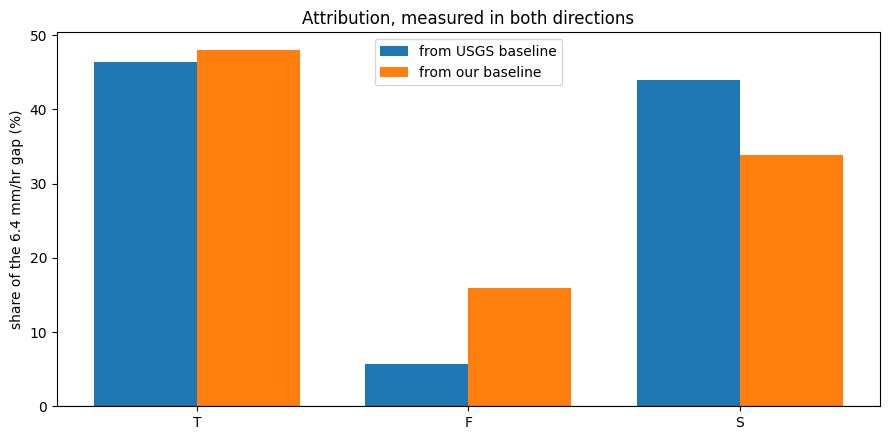

In [15]:
# Cell 9 --- reverse swaps: attribution measured from the other baseline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recompute the weights locally rather than trusting the name to be intact.
w = pieces.area_m2.to_numpy()

REVERSE = {
    'rev swap T': ('T_usgs', 'F_ours', 'S_ours'),   # ours, but their T
    'rev swap F': ('T_ours', 'F_usgs', 'S_ours'),
    'rev swap S': ('T_ours', 'F_ours', 'S_usgs'),
}

for label, (tc, fc, sc) in REVERSE.items():
    results[label] = run(pieces[tc], pieces[fc], pieces[sc])
    print(f'ran {label}')

# base_thr is the all-USGS median, full_thr the all-ours median, both from cell 5.
gap = full_thr - base_thr          # negative: ours is lower
print(f'\nall USGS {base_thr:.3f} mm/hr, all ours {full_thr:.3f} mm/hr, '
      f'gap {gap:+.3f}')

rows_sym = []
for var, fwd, rev in [('T', 'swap T', 'rev swap T'),
                      ('F', 'swap F', 'rev swap F'),
                      ('S', 'swap S', 'rev swap S')]:
    f_med = wmedian(results[fwd][0], w)
    r_med = wmedian(results[rev][0], w)
    # Forward: how far swapping this variable moves us from the USGS baseline.
    fwd_share = (f_med - base_thr) / gap * 100
    # Reverse: how much of the gap remains when only this variable is theirs,
    # expressed as that variable's contribution.
    rev_share = (r_med - full_thr) / (-gap) * 100
    rows_sym.append({
        'variable': var,
        'fwd_median': f_med, 'fwd_share_pct': fwd_share,
        'rev_median': r_med, 'rev_share_pct': rev_share,
        'spread_pct': abs(fwd_share - rev_share),
        'range': f'{min(fwd_share, rev_share):.0f} to {max(fwd_share, rev_share):.0f}%',
    })

sym = pd.DataFrame(rows_sym)
print('\n--- Attribution measured from both baselines ---')
print(sym.round(2).to_string(index=False))

print(f'\nforward shares sum to {sym.fwd_share_pct.sum():.1f}%')
print(f'reverse shares sum to {sym.rev_share_pct.sum():.1f}%')
worst = sym.spread_pct.max()
print(f'largest disagreement between directions: {worst:.1f} percentage points')
if worst < 5:
    print('>>> Symmetric. A single share per variable is defensible.')
else:
    print('>>> Asymmetric. Report each variable as a range, not a point estimate.')

# --- Plot ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(sym))
ax.bar(x - 0.19, sym.fwd_share_pct, 0.38, label='from USGS baseline')
ax.bar(x + 0.19, sym.rev_share_pct, 0.38, label='from our baseline')
ax.set_xticks(x); ax.set_xticklabels(sym.variable)
ax.set_ylabel('share of the 6.4 mm/hr gap (%)')
ax.set_title('Attribution, measured in both directions')
ax.legend(); ax.axhline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

## Cell 10 — A seventh soil rule: component percentages that do not sum to 100

Zeroing null KF values closed 57% of the soil gap. Something else accounts for
the rest, and there is one concrete untested candidate.

STATSGO map units are made of components, each with a representative percentage
`comppct_r`. Those percentages do not always sum to 100. Notebook 01 found map
unit 662058 with three components summing to 87. `soils.weighted_mean`
renormalises over whatever weight is present, which is the reason it returns a
coverage figure alongside the mean.

An implementation that divides by 100 instead would produce a systematically
lower S, by exactly the fraction the percentages fall short. If USGS does that,
it stacks on top of the null handling and moves in the right direction.

Two new rules are computed:

5. Surface horizon, nulls zeroed, **divided by 100** rather than renormalised
6. Surface horizon, nulls dropped, **divided by 100** rather than renormalised

The cell first reports how far short the percentages actually fall, since if they
all sum to 100 this hypothesis is dead before it is tested and the size of the
shortfall bounds how much it could possibly explain.

--- Sum of comppct_r per STATSGO map unit ---
660456    100
660470    100
660471    100
660474    100
660484    100
660494    100
660499    100
660500    100
660501    100
660505    100

mean sum   : 100.0
median sum : 100.0
units at 100: 10 of 10

Maximum possible effect of dividing by 100 instead of renormalising: a factor of 1.000

--- KF per map unit, new rules ---
        dropped (ours)  zeroed  5 zeroed / 100  6 dropped / 100
660456          0.2967  0.2878          0.2878           0.2878
660470          0.2674  0.1765          0.1765           0.1765
660471          0.2715  0.2715          0.2715           0.2715
660474          0.2432  0.1970          0.1970           0.1970
660484          0.2121  0.1994          0.1994           0.1994
660494          0.2415  0.2125          0.2125           0.2125
660499          0.2628  0.2234          0.2234           0.2234
660500          0.2440  0.1586          0.1586           0.1586
660501          0.3390  0.3153          0.3153      

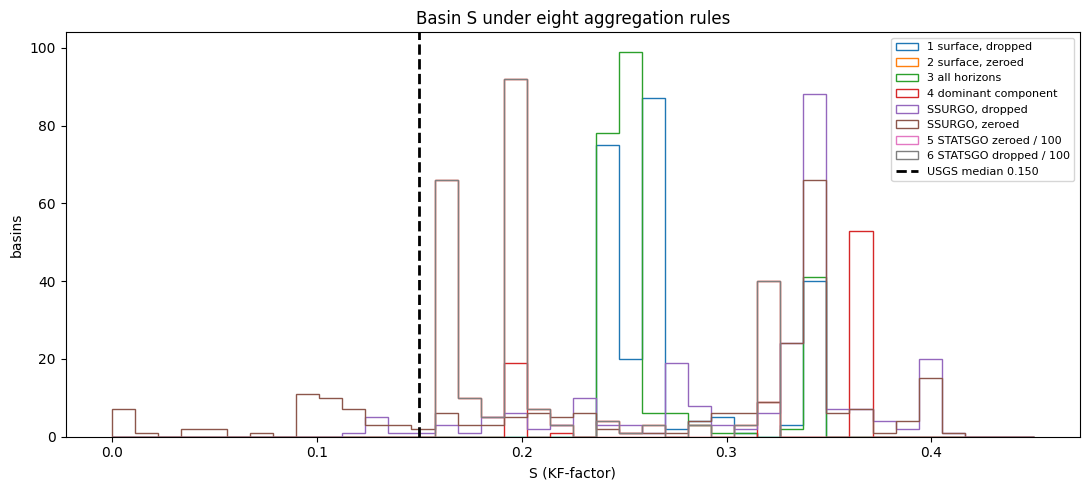

In [16]:
# Cell 10 --- do component percentages sum to 100, and does it matter?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- How far short do the percentages fall? -----------------------------------
pct_sums = {mukey: sum(c[0] for c in comps) for mukey, comps in by_mu.items()}
ps = pd.Series(pct_sums)
print('--- Sum of comppct_r per STATSGO map unit ---')
print(ps.sort_values().to_string())
print(f'\nmean sum   : {ps.mean():.1f}')
print(f'median sum : {ps.median():.1f}')
print(f'units at 100: {(ps == 100).sum()} of {len(ps)}')
print(f'\nMaximum possible effect of dividing by 100 instead of renormalising: '
      f'a factor of {ps.mean() / 100:.3f}')

# --- Rules 5 and 6 ------------------------------------------------------------
def wmean_over_100(kfs, pcts, zero_nulls):
    total = 0.0
    for kf, pct in zip(kfs, pcts):
        if kf != kf:                     # NaN
            if not zero_nulls:
                continue                 # dropped, but denominator stays 100
            kf = 0.0
        total += kf * pct
    return total / 100.0

rule5, rule6 = {}, {}
for mukey, comps in by_mu.items():
    pcts = [c[0] for c in comps]
    surf = [surface_kf(c[1]) for c in comps]
    rule5[mukey] = wmean_over_100(surf, pcts, zero_nulls=True)
    rule6[mukey] = wmean_over_100(surf, pcts, zero_nulls=False)

print('\n--- KF per map unit, new rules ---')
cmp_tab = pd.DataFrame({
    'dropped (ours)': variants['1 surface, dropped'],
    'zeroed': variants['2 surface, zeroed'],
    '5 zeroed / 100': rule5,
    '6 dropped / 100': rule6,
})
print(cmp_tab.round(4).to_string())

# --- Area weight onto our basins ----------------------------------------------
def basin_S_statsgo(lookup):
    out = []
    for bid, grp in inter.groupby('id'):
        kfs = [lookup.get(str(k), np.nan) for k in grp.mukey]
        val, _ = soils.weighted_mean(kfs, grp.area_m2.tolist())
        out.append({'id': bid, 'S': val})
    return pd.DataFrame(out).set_index('id')['S']

S5 = basin_S_statsgo(rule5).rename('5 STATSGO zeroed / 100')
S6 = basin_S_statsgo(rule6).rename('6 STATSGO dropped / 100')

all_S2 = pd.concat([all_S, S5, S6], axis=1)
summary2 = all_S2.describe().T[['mean', '50%', 'min', 'max']]
summary2['dist_from_USGS'] = (summary2['50%'] - usgs_S_med).abs()

print(f'\n--- All eight rules, vs USGS median of {usgs_S_med:.3f} ---')
print(summary2.round(4).sort_values('dist_from_USGS').to_string())

best2 = summary2.dist_from_USGS.idxmin()
print(f'\nclosest: {best2}  (median {summary2.loc[best2, "50%"]:.4f}, '
      f'USGS {usgs_S_med:.4f})')

# Pixelwise USGS S is the sounder comparison target than their basin median.
print(f'\nFor reference, the pixelwise USGS median S was 0.144 and this '
      f'project\'s was 0.254.')

fig, ax = plt.subplots(figsize=(11, 5))
for col in all_S2.columns:
    v = all_S2[col].dropna()
    if len(v):
        ax.hist(v, bins=40, range=(0.0, 0.45), histtype='step', lw=1.6, label=col)
ax.axvline(usgs_S_med, color='k', ls='--', lw=2, label=f'USGS median {usgs_S_med:.3f}')
ax.set_xlabel('S (KF-factor)'); ax.set_ylabel('basins'); ax.legend(fontsize=8)
ax.set_title('Basin S under eight aggregation rules')
plt.tight_layout(); plt.show()